In [1]:
#BLOCK 001 — Imports

import os
import re
import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler  # ✅ เพิ่ม WeightedRandomSampler

from PIL import Image
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

warnings.filterwarnings("ignore")

import random

print("✅ Imports OK")
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


✅ Imports OK
torch: 2.11.0+cpu
cuda: False


In [2]:
#BLOCK 002 — Config + Seed (5-fold subject-level SKF, fold-specific test)

from dataclasses import dataclass
from pathlib import Path
import numpy as np
import torch

@dataclass
class ExperimentConfig:
    # Paths
    data_root: str = r"./scalo_overall"   # <-- ชี้ไปโฟลเดอร์ scalogram (PTB/Healthy)
    output_dir: str = r"./reports_tb_screen_like_scalo"

    # Subject-level CV (same pattern as melspec notebook)
    n_runs: int = 5
    run_val_size: float = 0.25  # 25% of train_val -> 20% of total subjects per fold

    seed: int = 42

    # Image size (paper feed 448x224 PNG; เราใช้ H,W ใน torchvision Resize)
    image_size_hw: tuple = (224, 448)   # (H, W)

    # Training (paper-like)
    epochs: int = 60
    batch_size: int = 32
    weight_decay: float = 0.0

    # LR split (paper: feature=1e-6, head=1e-5)
    lr_backbone: float = 1e-6
    lr_head: float = 1e-5

    # StepLR (paper: *0.1 every 20 epochs)
    step_size: int = 20
    gamma: float = 0.1

    # Early stopping
    early_stop_patience: int = 10
    early_stop_min_delta: float = 0.0005

    # Dataset shaping to match paper T1 behavior
    make_subject_balanced: bool = False
    subjects_per_class: int = 45         # ถ้าของคุณมีไม่ถึง จะ auto ลดลงให้เท่าที่มี
    max_coughs_per_subject: int = 225    # cap ต่อ subject

    # Threshold policy
    target_sensitivity: float = 0.90

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # ---- SpecAugment (baseline OFF) ----
    use_specaugment: bool = False
    save_aug_examples: bool = False
    aug_examples_per_fold: int = 0

def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

config = ExperimentConfig()
set_seed(config.seed)

Path(config.output_dir).mkdir(parents=True, exist_ok=True)

print("✅ Config ready (5-fold subject-level SKF)")
print(config)
print("data_root exists:", Path(config.data_root).exists())
print("PTB exists:", (Path(config.data_root)/"PTB").exists())
print("Healthy exists:", (Path(config.data_root)/"Healthy").exists())
print("output_dir:", Path(config.output_dir).resolve())

✅ Config ready (5-fold subject-level SKF)
ExperimentConfig(data_root='./scalo_overall', output_dir='./reports_tb_screen_like_scalo', n_runs=5, run_val_size=0.25, seed=42, image_size_hw=(224, 448), epochs=60, batch_size=32, weight_decay=0.0, lr_backbone=1e-06, lr_head=1e-05, step_size=20, gamma=0.1, early_stop_patience=10, early_stop_min_delta=0.0005, make_subject_balanced=False, subjects_per_class=45, max_coughs_per_subject=225, target_sensitivity=0.9, device='cpu', use_specaugment=False, save_aug_examples=False, aug_examples_per_fold=0)
data_root exists: True
PTB exists: True
Healthy exists: True
output_dir: D:\TB-LATEST-CLONE\Tuberculosis_Classification_using_CoughSound\reports_tb_screen_like_scalo


In [3]:
#BLOCK 003 — Pretty print helpers (audio-like)

def banner(title: str, width: int = 70, char: str = "="):
    print(char * width)
    print(title.center(width))
    print(char * width)

def sub_banner(title: str, width: int = 60, char: str = "="):
    print(char * width)
    print(title)
    print(char * width)

def count_subjects_and_samples(df: pd.DataFrame) -> Dict[str, int]:
    n_samples = len(df)
    n_ptb = int((df["label"] == 1).sum())
    n_healthy = int((df["label"] == 0).sum())
    n_subjects = int(df["subject_id"].nunique())
    n_ptb_sub = int(df[df["label"] == 1]["subject_id"].nunique())
    n_healthy_sub = int(df[df["label"] == 0]["subject_id"].nunique())
    return {
        "subjects": n_subjects,
        "ptb_subjects": n_ptb_sub,
        "healthy_subjects": n_healthy_sub,
        "samples": n_samples,
        "ptb_samples": n_ptb,
        "healthy_samples": n_healthy
    }

def leakage_check(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> bool:
    tr = set(train_df["subject_id"].unique())
    va = set(val_df["subject_id"].unique())
    te = set(test_df["subject_id"].unique())
    return (tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te))



In [4]:
#BLOCK 004 — Build df from scalo_overall (subject_id = 3 digits)

def parse_subject_id_from_name(fname: str) -> str:
    # scalogram png: 001_02_seg_01_scalogram_10-4000Hz_448x224.png
    # => subject_id MUST be "001"
    m = re.match(r"^(\d{3})_", fname)
    if not m:
        raise ValueError(f"Filename does not match expected pattern ^(\\d{{3}})_: {fname}")
    return m.group(1)

def build_df_from_feature_root(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    rows = []

    for cls_name, label in [("PTB", 1), ("Healthy", 0)]:
        folder = root / cls_name
        if not folder.exists():
            raise FileNotFoundError(f"Missing folder: {folder}")

        img_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            img_files += list(folder.rglob(ext))

        for p in img_files:
            sid = parse_subject_id_from_name(p.name)
            rows.append({
                "wav_path": str(p),     # keep same column name as your notebook expects
                "label": int(label),
                "subject_id": sid,
                "file_name": p.name,
            })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No images found. Check PTB/Healthy folders and extensions.")

    df["subject_id"] = df["subject_id"].astype(str)
    df["label"] = df["label"].astype(int)

    print("✅ df built from scalogram images")
    print("Total samples:", len(df))
    print("Label counts:\n", df["label"].value_counts())
    print("Unique subjects:", df["subject_id"].nunique())
    return df

df = build_df_from_feature_root(config.data_root)
df.head()

✅ df built from scalogram images
Total samples: 512
Label counts:
 label
0    325
1    187
Name: count, dtype: int64
Unique subjects: 15


,wav_path,label,subject_id,file_name
0,scalo_overall\PTB\006_01_seg_01_scalogram_10-4...,1,006,006_01_seg_01_scalogram_10-4000Hz_448x224.png
1,scalo_overall\PTB\006_01_seg_02_scalogram_10-4...,1,006,006_01_seg_02_scalogram_10-4000Hz_448x224.png
2,scalo_overall\PTB\006_01_seg_03_scalogram_10-4...,1,006,006_01_seg_03_scalogram_10-4000Hz_448x224.png
3,scalo_overall\PTB\006_01_seg_04_scalogram_10-4...,1,006,006_01_seg_04_scalogram_10-4000Hz_448x224.png
4,scalo_overall\PTB\006_01_seg_05_scalogram_10-4...,1,006,006_01_seg_05_scalogram_10-4000Hz_448x224.png


In [5]:
#BLOCK 005 — subject_table (mode + sorted) + filters

def subject_table(df: pd.DataFrame) -> pd.DataFrame:
    # audio-like: label per subject uses MODE (not max)
    sub = df.groupby("subject_id")["label"].agg(
        lambda x: int(x.mode()[0]) if len(x.mode()) > 0 else int(x.iloc[0])
    ).reset_index()
    sub = sub.rename(columns={"label": "subject_label"})
    # IMPORTANT: deterministic order
    sub = sub.sort_values("subject_id").reset_index(drop=True)
    return sub

def filter_by_subjects(df: pd.DataFrame, subject_ids: np.ndarray) -> pd.DataFrame:
    return df[df["subject_id"].isin(set(subject_ids))].reset_index(drop=True)

# sanity
sub_df = subject_table(df)
print(sub_df.head())
print("subject_label counts:\n", sub_df["subject_label"].value_counts())


  subject_id  subject_label
0        001              0
1        002              0
2        003              0
3        004              0
4        005              0
subject_label counts:
 subject_label
0    8
1    7
Name: count, dtype: int64


In [6]:
#BLOCK 005B — SpecAugment2D (ON-THE-FLY) + save aug examples per fold

class SpecAugment2D(torch.nn.Module):
    """
    SpecAugment-style masking on tensor spectrogram images.
    Input tensor: [C,H,W] after ToTensor()
    Time axis = W, Frequency axis = H
    """
    def __init__(
        self,
        time_mask_max_frames=(25, 30),
        time_mask_count=(2, 4),
        frequency_mask_max_bins=(8, 10),
        frequency_mask_count=(1, 2),
        p=0.3,
        mask_value=0.0,
    ):
        super().__init__()
        self.time_mask_max_frames = time_mask_max_frames
        self.time_mask_count = time_mask_count
        self.frequency_mask_max_bins = frequency_mask_max_bins
        self.frequency_mask_count = frequency_mask_count
        self.p = p
        self.mask_value = mask_value

    def _randint(self, a, b):
        return random.randint(int(a), int(b))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.p < 1.0 and random.random() > self.p:
            return x

        C, H, W = x.shape
        x = x.clone()

        # time masks (mask columns)
        t_count = self._randint(*self.time_mask_count)
        for _ in range(t_count):
            t = min(self._randint(*self.time_mask_max_frames), W)
            if t <= 0:
                continue
            t0 = random.randint(0, max(0, W - t))
            x[:, :, t0:t0+t] = self.mask_value

        # freq masks (mask rows)
        f_count = self._randint(*self.frequency_mask_count)
        for _ in range(f_count):
            f = min(self._randint(*self.frequency_mask_max_bins), H)
            if f <= 0:
                continue
            f0 = random.randint(0, max(0, H - f))
            x[:, f0:f0+f, :] = self.mask_value

        return x


def _unnormalize_to_pil(x_norm: torch.Tensor, weights: ResNet18_Weights) -> Image.Image:
    """
    x_norm: normalized tensor [C,H,W] using weights mean/std
    """
    x = x_norm.detach().cpu().clone()
    mean = torch.tensor(weights.transforms().mean).view(3, 1, 1)
    std = torch.tensor(weights.transforms().std).view(3, 1, 1)
    x = x * std + mean
    x = x.clamp(0, 1)
    arr = (x.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)


def save_aug_examples_for_fold(train_df: pd.DataFrame, fold: int, tag: str):
    """
    Save N augmented examples from THIS fold's train_df.
    This does NOT affect training data and stays fold-independent.
    """
    if (not getattr(config, "save_aug_examples", False)) or int(getattr(config, "aug_examples_per_fold", 0)) <= 0:
        return
    n = int(config.aug_examples_per_fold)

    out_dir = Path(config.output_dir) / "aug_examples" / tag / f"fold_{fold:02d}"
    out_dir.mkdir(parents=True, exist_ok=True)

    # uses global AudioDataset + train_tf (augment=True)
    ds = AudioDataset(train_df, augment=True)
    n = min(n, len(ds))

    for i in range(n):
        x, y = ds[i]
        img = _unnormalize_to_pil(x, weights)
        img.save(out_dir / f"aug_{i:04d}_y{int(y.item())}.png")

    print(f"✅ Saved {n} augmented examples -> {out_dir}")


In [7]:
#BLOCK 006 — Transforms + Dataset (TBscreen-like; no SpecAug baseline)

weights = ResNet18_Weights.DEFAULT

def build_train_tf():
    # baseline: no SpecAug
    return T.Compose([
        T.Resize(config.image_size_hw),   # (H,W) = (224,448)
        T.ToTensor(),
        T.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    ])

def refresh_transforms():
    global train_tf
    train_tf = build_train_tf()

refresh_transforms()

val_tf = T.Compose([
    T.Resize(config.image_size_hw),
    T.ToTensor(),
    T.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

class AudioDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool):
        self.df = df.reset_index(drop=True)
        self.augment = augment  # keep for compatibility (but baseline uses same tf)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["wav_path"]).convert("RGB")
        img = train_tf(img) if self.augment else val_tf(img)
        y = torch.tensor(row["label"], dtype=torch.float32)
        return img, y

print("✅ Dataset ready (TBscreen-like transforms)")

✅ Dataset ready (TBscreen-like transforms)


In [8]:
#BLOCK 007 — Models (TBscreen-like ResNet18 + keep Simple 2D CNN)

def build_resnet18_binary(use_pretrained: bool = True, freeze_backbone: bool = False) -> nn.Module:
    w = ResNet18_Weights.DEFAULT if use_pretrained else None
    m = resnet18(weights=w)
    in_f = m.fc.in_features

    # TBscreen-like: replace single dense with 2 dense layers + ReLU
    m.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 128),
        nn.ReLU(inplace=False),
        nn.Dropout(0.5),
        nn.Linear(128, 1)
        
    )

    if freeze_backbone:
        for name, p in m.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False
    return m

class SimpleCNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        # Return logits (no sigmoid). Sigmoid is applied only for scoring/evaluation.
        self.head = nn.Sequential(
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.head(x)

print("✅ Models defined (logit outputs for BCEWithLogitsLoss)")

✅ Models defined (logit outputs for BCEWithLogitsLoss)


In [9]:
#BLOCK 008 — EarlyStopper (audio-like)

class EarlyStopperAudioLike:
    def __init__(self, patience: int, min_delta: float):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float("inf")
        self.best_state = None
        self.bad_epochs = 0
        self.best_epoch = 0

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        improved = val_loss < (self.best_val_loss - self.min_delta)
        if improved:
            self.best_val_loss = val_loss
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.bad_epochs = 0
            self.best_epoch = epoch
        else:
            self.bad_epochs += 1
        return self.bad_epochs >= self.patience

    def restore(self, model: nn.Module, device: str):
        if self.best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_state.items()})


In [10]:
#BLOCK 009 — ThresholdSelector (FIXED: adds find_threshold)

import numpy as np

class ThresholdSelector:
    """
    Select a decision threshold based on validation labels + scores.

    Goal (default): choose the *highest* threshold such that sensitivity >= target_sensitivity.
    This tends to maximize specificity while meeting the sensitivity target.

    If target cannot be achieved (e.g., all positives scored too low),
    it will fall back to the threshold that gives the best sensitivity (usually the minimum score),
    but still returns a valid float.
    """
    def __init__(self, target_sensitivity: float = 0.90, eps: float = 1e-12):
        self.target_sensitivity = float(target_sensitivity)
        self.eps = float(eps)

    @staticmethod
    def _safe_div(a: float, b: float, eps: float = 1e-12) -> float:
        return float(a) / float(b + eps)

    def find_threshold(self, y_true, scores) -> float:
        """
        y_true: array-like of {0,1}
        scores: array-like float (higher => more positive)
        returns: threshold float
        """
        y = np.asarray(y_true).astype(int)
        s = np.asarray(scores).astype(float)

        # Edge cases
        if len(y) == 0:
            return 0.5
        if np.all(s == s[0]):
            # all scores identical → any threshold gives same ranking, use 0.5-ish
            return float(s[0])

        # Sort candidate thresholds from high to low (unique scores)
        thresholds = np.unique(s)[::-1]

        # If no positives in validation, can't define sensitivity target meaningfully
        pos_total = int((y == 1).sum())
        neg_total = int((y == 0).sum())
        if pos_total == 0:
            # choose threshold that avoids predicting all positive (maximize specificity)
            # Here: set threshold above max score to predict all negatives
            return float(np.max(s) + 1e-6)
        if neg_total == 0:
            # only positives → threshold below min to predict all positives
            return float(np.min(s) - 1e-6)

        best_thr = float(thresholds[-1])  # fallback: lowest threshold (max sensitivity)
        best_sens = -1.0
        best_spec = -1.0

        for thr in thresholds:
            yhat = (s >= thr).astype(int)
            tp = int(((yhat == 1) & (y == 1)).sum())
            fn = int(((yhat == 0) & (y == 1)).sum())
            tn = int(((yhat == 0) & (y == 0)).sum())
            fp = int(((yhat == 1) & (y == 0)).sum())

            sens = self._safe_div(tp, tp + fn, self.eps)
            spec = self._safe_div(tn, tn + fp, self.eps)

            # Track best sensitivity fallback
            if sens > best_sens or (abs(sens - best_sens) < 1e-9 and spec > best_spec):
                best_sens = sens
                best_spec = spec
                best_thr = float(thr)

        # Now pick the highest threshold meeting sensitivity target
        chosen_thr = None
        for thr in thresholds:
            yhat = (s >= thr).astype(int)
            tp = int(((yhat == 1) & (y == 1)).sum())
            fn = int(((yhat == 0) & (y == 1)).sum())
            sens = self._safe_div(tp, tp + fn, self.eps)

            if sens + 1e-12 >= self.target_sensitivity:
                chosen_thr = float(thr)
                break  # because thresholds are descending → first hit is highest thr

        return chosen_thr if chosen_thr is not None else best_thr

    # Optional: allow calling instance directly: selector(y, s)
    def __call__(self, y_true, scores) -> float:
        return self.find_threshold(y_true, scores)


In [11]:
#BLOCK 010 — Metrics (paper-like reporting: thr=0.5 + Sens@70%Spec)

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

def sensitivity_at_specificity(y_true, y_score, target_spec=0.70):
    """
    Returns: (sens_at_target, spec_at_target, threshold_at_target)
    Uses ROC curve points; selects the point whose specificity is closest to target_spec.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if len(np.unique(y_true)) < 2:
        return (np.nan, np.nan, np.nan)

    fpr, tpr, thr = roc_curve(y_true, y_score)
    spec = 1.0 - fpr

    idx = int(np.argmin(np.abs(spec - target_spec)))
    return float(tpr[idx]), float(spec[idx]), float(thr[idx])

def compute_metrics_at_threshold(y_true, y_score, threshold=0.5):
    """
    Confusion-matrix metrics at fixed threshold (paper: 0.5).
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= float(threshold)).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    f1   = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) else np.nan

    return {
        "threshold": float(threshold),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "accuracy": float(acc),
        "precision": float(prec),
        "f1": float(f1),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }

def compute_metrics(y_true, y_pred_unused, y_score):
    """
    Compatibility wrapper.
    Downstream calls compute_metrics(y_true, y_pred, y_score) — we ignore y_pred
    and compute everything from y_score + threshold policy (paper-like).
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    # AUROC / AUPRC (only valid if both classes exist)
    if len(np.unique(y_true)) == 2:
        auroc = float(roc_auc_score(y_true, y_score))
        auprc = float(average_precision_score(y_true, y_score))
    else:
        auroc = np.nan
        auprc = np.nan

    # Fixed threshold metrics (paper uses 0.5)
    fixed = compute_metrics_at_threshold(y_true, y_score, threshold=0.5)

    # Sensitivity at 70% specificity (paper reports this too)
    sens70, spec70, thr70 = sensitivity_at_specificity(y_true, y_score, target_spec=0.70)

    out = {
        "roc_auc": auroc,
        "auprc": auprc,
        "sensitivity": fixed["sensitivity"],
        "specificity": fixed["specificity"],
        "accuracy": fixed["accuracy"],
        "f1": fixed["f1"],
        "threshold": fixed["threshold"],
        "sens_at_70spec": sens70,
        "spec_at_70spec": spec70,
        "thr_at_70spec": thr70,

        # keep uppercase aliases (เผื่อโค้ดเก่า)
        "AUROC": auroc,
        "AUPRC": auprc,
        "Sensitivity": fixed["sensitivity"],
        "Specificity": fixed["specificity"],
        "Accuracy": fixed["accuracy"],
        "F1": fixed["f1"],
    }
    return out

In [12]:
#BLOCK 012 — Training loop (TBscreen-like: Adam + LR split + StepLR)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def train_model_audio_like(model: nn.Module, train_df, val_df, title: str):
    device = config.device
    model = model.to(device)

    # datasets
    train_dataset = AudioDataset(train_df, augment=True)
    val_dataset   = AudioDataset(val_df, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # Use logits-based BCE for numerical stability.
    criterion = nn.BCEWithLogitsLoss()

    # LR split: backbone vs head (fc)
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if name.startswith("fc."):
            head_params.append(p)
        else:
            backbone_params.append(p)

    optimizer = optim.Adam(
        [
            {"params": backbone_params, "lr": config.lr_backbone},
            {"params": head_params, "lr": config.lr_head},
        ],
        weight_decay=config.weight_decay
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=config.step_size,
        gamma=config.gamma
    )

    stopper = EarlyStopperAudioLike(config.early_stop_patience, config.early_stop_min_delta)

    print(f"🚀 Training {title} ...")
    print(f"  train samples={len(train_df)} | val samples={len(val_df)}")
    print(f"  LR backbone={config.lr_backbone} | LR head={config.lr_head} | batch={config.batch_size}")
    print(f"  StepLR: step_size={config.step_size}, gamma={config.gamma}")
    print("  (Oversampling OFF)\n")

    history = {"epoch": [], "train_loss": [], "val_loss": []}
    best_state = None
    best_epoch = 0
    best_val = float("inf")

    for epoch in range(1, config.epochs + 1):
        model.train()
        tr_losses = []

        for x, yb in train_loader:
            x = x.to(device)
            yb = yb.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        tr_loss = float(np.mean(tr_losses)) if tr_losses else float("nan")

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xv, yv in val_loader:
                xv = xv.to(device)
                yv = yv.to(device).unsqueeze(1)
                logits_v = model(xv)
                loss_v = criterion(logits_v, yv)
                va_losses.append(loss_v.item())

        va_loss = float(np.mean(va_losses)) if va_losses else float("nan")

        scheduler.step()

        print(f"  Epoch {epoch:03d}/{config.epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

        history["epoch"].append(epoch)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        # early stop (your stopper expects: (val_loss, model, epoch))
        stop = stopper.step(va_loss, model, epoch)
        if va_loss < best_val:
            best_val = va_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if stop:
            print("🛑 Early stopping triggered.")
            break

    # restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch, best_val

In [13]:
#BLOCK 013 — Predict scores (convert logits -> probabilities)

@torch.no_grad()
def predict_scores(model: nn.Module, df: pd.DataFrame) -> np.ndarray:
    device = config.device
    model.eval()
    loader = DataLoader(AudioDataset(df, augment=False),
                        batch_size=config.batch_size, shuffle=False, num_workers=0)
    out = []
    for x, _ in loader:
        x = x.to(device)
        probs = torch.sigmoid(model(x)).squeeze(1).detach().cpu().numpy()
        out.append(probs)
    return np.concatenate(out)

In [14]:
#BLOCK 014 — Subject-level 5-fold SKF + inner train/val split per fold (same pattern as melspec)

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from pathlib import Path
import numpy as np
import pandas as pd
import re

def _extract_subject_id_from_path(path_like: str) -> str:
    if pd.isna(path_like):
        raise ValueError("Cannot infer subject_id from NaN value")

    text = str(path_like)
    name = Path(text).name
    stem = Path(text).stem

    # Try strict and relaxed patterns over filename, stem, then full text.
    patterns = [r"^(\d{3})_", r"^(\d+)_", r"(\d{3,})"]
    for candidate in (name, stem, text):
        for pat in patterns:
            m = re.search(pat, candidate)
            if m:
                return m.group(1)

    raise ValueError(
        f"Cannot infer subject_id from value: {path_like}. "
        "Expected subject-style digits in file_name or wav_path."
    )

def ensure_subject_id_column(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()

    has_file_name = "file_name" in tmp.columns
    has_wav_path = "wav_path" in tmp.columns

    if not has_file_name and not has_wav_path and "subject_id" not in tmp.columns:
        raise KeyError(
            "Missing 'subject_id' and cannot infer it because neither "
            "'file_name' nor 'wav_path' exists in DataFrame columns."
        )

    def infer_one_row(row) -> str:
        candidates = []
        if has_file_name:
            candidates.append(row.get("file_name", np.nan))
        if has_wav_path:
            candidates.append(row.get("wav_path", np.nan))

        for c in candidates:
            try:
                return _extract_subject_id_from_path(c)
            except Exception:
                continue

        raise ValueError(
            "Cannot infer subject_id for one row. "
            "Check values in file_name/wav_path."
        )

    # Case 1: column does not exist -> create it
    if "subject_id" not in tmp.columns:
        tmp["subject_id"] = tmp.apply(infer_one_row, axis=1)
        tmp["subject_id"] = tmp["subject_id"].astype(str)
        print("ℹ️ subject_id column generated from file metadata.")
        return tmp

    # Case 2: column exists but has missing/empty values -> fill missing only
    raw_sid = tmp["subject_id"]
    sid_as_str = raw_sid.astype(str)
    missing_mask = raw_sid.isna() | (sid_as_str.str.strip() == "") | (sid_as_str.str.lower() == "nan")
    if missing_mask.any():
        tmp_missing = tmp.loc[missing_mask].copy()
        tmp.loc[missing_mask, "subject_id"] = tmp_missing.apply(infer_one_row, axis=1).values
        print(f"ℹ️ Filled subject_id for {int(missing_mask.sum())} rows from file metadata.")

    tmp["subject_id"] = tmp["subject_id"].astype(str)
    return tmp

def build_subject_table_from_df(df: pd.DataFrame) -> pd.DataFrame:
    tmp = ensure_subject_id_column(df)
    tmp["label"] = tmp["label"].astype(int)

    def mode_int(x):
        vc = x.value_counts()
        return int(vc.idxmax())

    st = (
        tmp.groupby("subject_id")["label"]
        .apply(mode_int)
        .reset_index()
        .rename(columns={"label": "subject_label"})
        .sort_values("subject_id")
        .reset_index(drop=True)
    )
    return st

def make_subject_balanced(st: pd.DataFrame, n_per_class: int, seed: int) -> pd.DataFrame:
    st0 = st[st["subject_label"] == 0]
    st1 = st[st["subject_label"] == 1]
    n = min(n_per_class, len(st0), len(st1))
    out = pd.concat(
        [st0.sample(n=n, random_state=seed), st1.sample(n=n, random_state=seed)],
        axis=0
    ).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    print(f"✅ Subject-balanced: n0={n}, n1={n} (total subjects={len(out)})")
    return out

def cap_samples_per_subject(df: pd.DataFrame, max_per_subject: int, seed: int) -> pd.DataFrame:
    tmp = ensure_subject_id_column(df)
    parts = []
    for _, g in tmp.groupby("subject_id", sort=False):
        parts.append(g.sample(n=min(len(g), max_per_subject), random_state=seed))
    out = pd.concat(parts, axis=0).reset_index(drop=True)
    out["subject_id"] = out["subject_id"].astype(str)
    return out

def _split_stats(df_samples: pd.DataFrame, subject_ids, split_name: str, total_n: int):
    df_subset = df_samples[df_samples["subject_id"].isin(set(subject_ids))]
    n_ptb_seg = int((df_subset["label"] == 1).sum())
    n_h_seg = int((df_subset["label"] == 0).sum())
    ratio = len(subject_ids) / total_n if total_n else 0.0
    print(
        f"{split_name}: subjects={len(subject_ids)} ({ratio:.2%}) | "
        f"PTB seg={n_ptb_seg} | Healthy seg={n_h_seg}"
    )

def build_cv_folds(df: pd.DataFrame):
    banner("Building subject-level 5-fold SKF with fold-specific test", 80)

    # Ensure this block is robust even if df came from a different preprocessing path.
    df = ensure_subject_id_column(df)

    # Optional subject balance (paper-like option)
    st = build_subject_table_from_df(df)
    if getattr(config, "make_subject_balanced", False):
        st = make_subject_balanced(st, n_per_class=config.subjects_per_class, seed=config.seed)
        df = filter_by_subjects(df, st["subject_id"].values)

    # Cap per subject
    df = cap_samples_per_subject(df, max_per_subject=config.max_coughs_per_subject, seed=config.seed)

    # Re-ensure key column after any reshaping
    df = ensure_subject_id_column(df)
    if "subject_id" not in df.columns:
        raise KeyError(f"subject_id not found after preprocessing. columns={list(df.columns)}")

    st = build_subject_table_from_df(df)

    # Sanity: each subject should map to one label
    assert df.groupby("subject_id")["label"].nunique().max() == 1, (
        "A subject has multiple labels. Please inspect source data."
    )

    X_subj = st["subject_id"].values
    y_subj = st["subject_label"].values

    outer_skf = StratifiedKFold(n_splits=config.n_runs, shuffle=True, random_state=config.seed)
    runs = []

    for fold_i, (train_val_idx, test_idx) in enumerate(outer_skf.split(X_subj, y_subj), start=1):
        train_val_subj = X_subj[train_val_idx]
        y_train_val = y_subj[train_val_idx]
        test_subj = X_subj[test_idx]

        inner_split = StratifiedShuffleSplit(
            n_splits=1,
            test_size=config.run_val_size,
            random_state=config.seed + fold_i,
        )
        inner_train_idx, inner_val_idx = next(inner_split.split(train_val_subj, y_train_val))
        train_subj_ids = train_val_subj[inner_train_idx]
        val_subj_ids = train_val_subj[inner_val_idx]

        tr_ids = set([str(s) for s in train_subj_ids.tolist()])
        va_ids = set([str(s) for s in val_subj_ids.tolist()])
        te_ids = set([str(s) for s in test_subj.tolist()])

        ok = tr_ids.isdisjoint(va_ids) and tr_ids.isdisjoint(te_ids) and va_ids.isdisjoint(te_ids)
        print(f"{'✅' if ok else '❌'} Fold {fold_i}: train/val/test subjects disjoint")

        run_train_df = filter_by_subjects(df, train_subj_ids)
        run_val_df = filter_by_subjects(df, val_subj_ids)
        run_test_df = filter_by_subjects(df, test_subj)

        runs.append({
            "run": int(fold_i),
            "fold": int(fold_i),
            "train_subjects": sorted([str(s) for s in train_subj_ids.tolist()]),
            "val_subjects": sorted([str(s) for s in val_subj_ids.tolist()]),
            "test_subjects": sorted([str(s) for s in test_subj.tolist()]),
            "train_df": run_train_df,
            "val_df": run_val_df,
            "test_df": run_test_df,
            "seed": config.seed + fold_i,
        })

        n_total = len(X_subj)
        _split_stats(df, train_subj_ids, "Train", n_total)
        _split_stats(df, val_subj_ids, "Val", n_total)
        _split_stats(df, test_subj, "Test", n_total)

    info = {
        "subject_table": st,
        "runs": runs,
    }

    banner("5-fold setup complete", 80)
    print(f"✅ Total subjects: {len(st)}")
    print(f"✅ Number of folds: {len(runs)}")
    print(f"✅ Total samples after cap: {len(df)}")
    return info

split_info = build_cv_folds(df)

#BLOCK 014B — Quick check
banner("QUICK CHECK — FOLD SPLITS", 80)
for r in split_info["runs"]:
    print(
        f"Fold {r['run']}: train_subjects={len(r['train_subjects'])} | "
        f"val_subjects={len(r['val_subjects'])} | test_subjects={len(r['test_subjects'])}"
    )
    print("  test subjects (sorted, first 30):", sorted(r["test_subjects"])[:30])

           Building subject-level 5-fold SKF with fold-specific test            
✅ Fold 1: train/val/test subjects disjoint
Train: subjects=9 (60.00%) | PTB seg=125 | Healthy seg=133
Val: subjects=3 (20.00%) | PTB seg=20 | Healthy seg=150
Test: subjects=3 (20.00%) | PTB seg=42 | Healthy seg=42
✅ Fold 2: train/val/test subjects disjoint
Train: subjects=9 (60.00%) | PTB seg=149 | Healthy seg=103
Val: subjects=3 (20.00%) | PTB seg=1 | Healthy seg=150
Test: subjects=3 (20.00%) | PTB seg=37 | Healthy seg=72
✅ Fold 3: train/val/test subjects disjoint
Train: subjects=9 (60.00%) | PTB seg=129 | Healthy seg=173
Val: subjects=3 (20.00%) | PTB seg=38 | Healthy seg=32
Test: subjects=3 (20.00%) | PTB seg=20 | Healthy seg=120
✅ Fold 4: train/val/test subjects disjoint
Train: subjects=9 (60.00%) | PTB seg=162 | Healthy seg=224
Val: subjects=3 (20.00%) | PTB seg=20 | Healthy seg=51
Test: subjects=3 (20.00%) | PTB seg=5 | Healthy seg=50
✅ Fold 5: train/val/test subjects disjoint
Train: subjects=9 (60.0

In [15]:
df

,wav_path,label,subject_id,file_name
0,scalo_overall\PTB\006_01_seg_01_scalogram_10-4...,1,006,006_01_seg_01_scalogram_10-4000Hz_448x224.png
1,scalo_overall\PTB\006_01_seg_02_scalogram_10-4...,1,006,006_01_seg_02_scalogram_10-4000Hz_448x224.png
2,scalo_overall\PTB\006_01_seg_03_scalogram_10-4...,1,006,006_01_seg_03_scalogram_10-4000Hz_448x224.png
3,scalo_overall\PTB\006_01_seg_04_scalogram_10-4...,1,006,006_01_seg_04_scalogram_10-4000Hz_448x224.png
4,scalo_overall\PTB\006_01_seg_05_scalogram_10-4...,1,006,006_01_seg_05_scalogram_10-4000Hz_448x224.png
...,...,...,...,...
507,scalo_overall\Healthy\014_14_seg_03_scalogram_...,0,014,014_14_seg_03_scalogram_10-4000Hz_448x224.png
508,scalo_overall\Healthy\014_14_seg_04_scalogram_...,0,014,014_14_seg_04_scalogram_10-4000Hz_448x224.png
509,scalo_overall\Healthy\014_15_seg_01_scalogram_...,0,014,014_15_seg_01_scalogram_10-4000Hz_448x224.png
510,scalo_overall\Healthy\014_15_seg_02_scalogram_...,0,014,014_15_seg_02_scalogram_10-4000Hz_448x224.png


In [16]:
#BLOCK 015 — 5-FOLD subject-level CV (fold-specific test)

import numpy as np

def train_eval_one_fold(
    fold_train_df,
    fold_val_df,
    fold_test_df,
    build_model_fn,
    model_name: str,
    fold_id: int,
):
    title = f"[FOLD {fold_id}] {model_name}"
    model = build_model_fn()

    model, history, best_epoch, best_val = train_model_audio_like(
        model, fold_train_df, fold_val_df, title=title
    )

    # Validation scores for threshold selection
    y_val = fold_val_df["label"].values.astype(int)
    s_val = predict_scores(model, fold_val_df)

    selector = ThresholdSelector(target_sensitivity=config.target_sensitivity)
    thr = float(selector.find_threshold(y_val, s_val))
    val_metrics = compute_metrics_at_threshold(y_val, s_val, threshold=thr)

    # Fold-specific test evaluation
    y_test = fold_test_df["label"].values.astype(int)
    s_test = predict_scores(model, fold_test_df)
    test_metrics = compute_metrics_at_threshold(y_test, s_test, threshold=thr)

    if len(np.unique(y_test)) == 2:
        test_auroc = float(roc_auc_score(y_test, s_test))
        test_auprc = float(average_precision_score(y_test, s_test))
    else:
        test_auroc = np.nan
        test_auprc = np.nan

    sens70, spec70, thr70 = sensitivity_at_specificity(y_test, s_test, target_spec=0.70)

    return {
        "selected_threshold": thr,
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val),

        "y_val": y_val,
        "scores_val": s_val,
        "val_metrics": val_metrics,

        "y": y_test,
        "scores": s_test,
        "test_metrics": test_metrics,
        "roc_auc": test_auroc,
        "auprc": test_auprc,
        "sens_at_70spec": sens70,
        "spec_at_70spec": spec70,
        "thr_at_70spec": thr70,
        "confusion_matrix": {
            "tn": int(test_metrics["tn"]),
            "fp": int(test_metrics["fp"]),
            "fn": int(test_metrics["fn"]),
            "tp": int(test_metrics["tp"]),
        },

        "model_obj": model,
        "history": history,
    }

def run_cv_5folds(split_info, tag: str):
    banner(f"RUNNING 5-FOLD CV — {tag.upper()}", 80)

    runs = split_info["runs"]

    def build_model_a():
        return build_resnet18_binary(use_pretrained=True, freeze_backbone=False)

    # def build_model_b():
    #     return SimpleCNN2D()

    model_builders = {
        "Model A (ResNet18 TBscreen-like)": build_model_a,
        # "Model B (2D CNN)": build_model_b,
    }

    run_results = []
    for model_key, build_fn in model_builders.items():
        banner(f"MODEL: {model_key}", 60)

        for r in runs:
            res = train_eval_one_fold(
                fold_train_df=r["train_df"],
                fold_val_df=r["val_df"],
                fold_test_df=r["test_df"],
                build_model_fn=build_fn,
                model_name=model_key,
                fold_id=r["run"],
            )
            res["model_key"] = model_key
            res["run"] = r["run"]
            res["fold"] = r["fold"]
            res["tag"] = tag
            res["test_subjects"] = r["test_subjects"]
            run_results.append(res)

            tm = res["test_metrics"]
            auc = res.get("roc_auc", np.nan)
            auprc = res.get("auprc", np.nan)
            sens = tm.get("sensitivity", np.nan)
            spec = tm.get("specificity", np.nan)
            acc = tm.get("accuracy", np.nan)
            f1 = tm.get("f1", np.nan)
            sens70 = res.get("sens_at_70spec", np.nan)
            thr = res.get("selected_threshold", np.nan)

            print(
                f"✅ {model_key} FOLD {r['run']} | TEST AUROC={auc:.4f} | AUPRC={auprc:.4f} | "
                f"thr={thr:.4f} | Sens={sens:.4f} | Spec={spec:.4f} | ACC={acc:.4f} | F1={f1:.4f} | Sens@70%Spec={sens70:.4f}"
            )

    banner(f"DONE — {tag.upper()}", 80)
    return run_results

run_results_baseline = run_cv_5folds(split_info, tag="baseline")

                          RUNNING 5-FOLD CV — BASELINE                          
          MODEL: Model A (ResNet18 TBscreen-like)           
🚀 Training [FOLD 1] Model A (ResNet18 TBscreen-like) ...
  train samples=258 | val samples=170
  LR backbone=1e-06 | LR head=1e-05 | batch=32
  StepLR: step_size=20, gamma=0.1
  (Oversampling OFF)

  Epoch 001/60 | train_loss=0.7543 | val_loss=0.8184
  Epoch 002/60 | train_loss=0.7175 | val_loss=0.7840
  Epoch 003/60 | train_loss=0.7401 | val_loss=0.7757
  Epoch 004/60 | train_loss=0.7235 | val_loss=0.7662
  Epoch 005/60 | train_loss=0.7038 | val_loss=0.7520
  Epoch 006/60 | train_loss=0.6896 | val_loss=0.7502
  Epoch 007/60 | train_loss=0.6927 | val_loss=0.7361
  Epoch 008/60 | train_loss=0.7089 | val_loss=0.7282
  Epoch 009/60 | train_loss=0.6710 | val_loss=0.7295
  Epoch 010/60 | train_loss=0.6908 | val_loss=0.7273
  Epoch 011/60 | train_loss=0.6852 | val_loss=0.7213
  Epoch 012/60 | train_loss=0.6635 | val_loss=0.7042
  Epoch 013/60 | train_l

In [17]:
#BLOCK 016A — ROC/PR for 5 folds (fold-specific test) + Mean ROC

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

def plot_runs_roc_pr_new(
    run_results,
    model_key: str,
    out_path: str,
    title_prefix: str,
    show: bool = True,
    mean_grid_n: int = 200
):
    """
    run_results: list of dicts
      each item has: {"model_key","run","y","scores", ...}
    """

    runs = []
    for r in run_results:
        if r.get("model_key") != model_key:
            continue
        y = np.asarray(r["y"], dtype=int)
        s = np.asarray(r["scores"], dtype=float)
        runs.append((y, s, r.get("run", None)))

    if len(runs) == 0:
        print(f"⚠️ No runs found for model_key={model_key}")
        return

    prevalence = float(runs[0][0].mean())

    fig = plt.figure(figsize=(14, 5))

    # ROC
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_title(f"ROC — {title_prefix}")
    ax1.set_xlabel("False Positive Rate (1 - Specificity)")
    ax1.set_ylabel("True Positive Rate (Sensitivity)")

    fprs, tprs, aucs = [], [], []

    for (y, s, run_id) in runs:
        if len(np.unique(y)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y, s)
        auc_val = roc_auc_score(y, s)

        label = f"Fold {run_id} (AUC={auc_val:.3f})" if run_id is not None else f"Run (AUC={auc_val:.3f})"
        ax1.plot(fpr, tpr, linewidth=1.5, alpha=0.35, label=label)

        fprs.append(fpr)
        tprs.append(tpr)
        aucs.append(auc_val)

    if len(fprs) >= 2:
        mean_fpr = np.linspace(0, 1, mean_grid_n)
        interp_tprs = []
        for fpr, tpr in zip(fprs, tprs):
            tpr_i = np.interp(mean_fpr, fpr, tpr)
            tpr_i[0] = 0.0
            interp_tprs.append(tpr_i)

        mean_tpr = np.mean(np.vstack(interp_tprs), axis=0)
        mean_tpr[-1] = 1.0

        mean_auc = float(np.mean(aucs))
        std_auc = float(np.std(aucs, ddof=1)) if len(aucs) > 1 else 0.0

        ax1.plot(
            mean_fpr, mean_tpr, linewidth=3.5, alpha=0.95,
            label=f"Mean ROC (AUC={mean_auc:.3f}+-{std_auc:.3f})"
        )

    ax1.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, alpha=0.7, label="Random")
    ax1.legend(loc="lower right")

    # PR
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_title(f"PR — {title_prefix}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")

    for (y, s, run_id) in runs:
        if len(np.unique(y)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        label = f"Fold {run_id} (AP={ap:.3f})" if run_id is not None else f"Run (AP={ap:.3f})"
        ax2.plot(rec, prec, linewidth=1.5, alpha=0.35, label=label)

    ax2.hlines(
        prevalence, 0, 1, linestyles="--", linewidth=1.5, alpha=0.7,
        label=f"Prevalence={prevalence:.3f}"
    )
    ax2.legend(loc="lower left")

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    if show:
        plt.show()
    plt.close(fig)

In [18]:
#BLOCK 016B — Summary table (5-fold fold-specific test metrics)

import numpy as np
import pandas as pd

def _mean_std(vals):
    vals = np.array(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return (np.nan, np.nan)
    if len(vals) == 1:
        return (float(vals.mean()), 0.0)
    return (float(vals.mean()), float(vals.std(ddof=1)))

def _fmt_ms(ms):
    m, s = ms
    return f"{m:.3f} +- {s:.3f}"

def summarize_runs_new(run_results, model_key):
    aucs, auprcs, sens, spec, accs, f1s, sens70, thr = [], [], [], [], [], [], [], []

    for r in run_results:
        if r.get("model_key") != model_key:
            continue

        tm = r.get("test_metrics", {})
        aucs.append(r.get("roc_auc", np.nan))
        auprcs.append(r.get("auprc", np.nan))
        sens.append(tm.get("sensitivity", np.nan))
        spec.append(tm.get("specificity", np.nan))
        accs.append(tm.get("accuracy", np.nan))
        f1s.append(tm.get("f1", np.nan))
        sens70.append(r.get("sens_at_70spec", np.nan))
        thr.append(r.get("selected_threshold", np.nan))

    return {
        "AUROC (mean+-sd)": _fmt_ms(_mean_std(aucs)),
        "AUPRC (mean+-sd)": _fmt_ms(_mean_std(auprcs)),
        "Sensitivity @ selected thr (mean+-sd)": _fmt_ms(_mean_std(sens)),
        "Specificity @ selected thr (mean+-sd)": _fmt_ms(_mean_std(spec)),
        "Accuracy @ selected thr (mean+-sd)": _fmt_ms(_mean_std(accs)),
        "F1 @ selected thr (mean+-sd)": _fmt_ms(_mean_std(f1s)),
        "Sensitivity @ 70% Spec (mean+-sd)": _fmt_ms(_mean_std(sens70)),
        "Selected threshold (mean+-sd)": _fmt_ms(_mean_std(thr)),
    }

def print_baseline_table(run_results):
    model_keys = sorted(set([r["model_key"] for r in run_results]))
    rows = {mk: summarize_runs_new(run_results, mk) for mk in model_keys}
    df_sum = pd.DataFrame(rows).T
    df_sum.index.name = "Model"
    display(df_sum)

print_baseline_table(run_results_baseline)

,AUROC (mean+-sd),AUPRC (mean+-sd),Sensitivity @ selected thr (mean+-sd),Specificity @ selected thr (mean+-sd),Accuracy @ selected thr (mean+-sd),F1 @ selected thr (mean+-sd),Sensitivity @ 70% Spec (mean+-sd),Selected threshold (mean+-sd)
Model,,,,,,,,
Model A (ResNet18 TBscreen-like),0.633 +- 0.108,0.445 +- 0.230,0.825 +- 0.170,0.312 +- 0.181,0.494 +- 0.190,0.483 +- 0.264,0.395 +- 0.184,0.410 +- 0.106


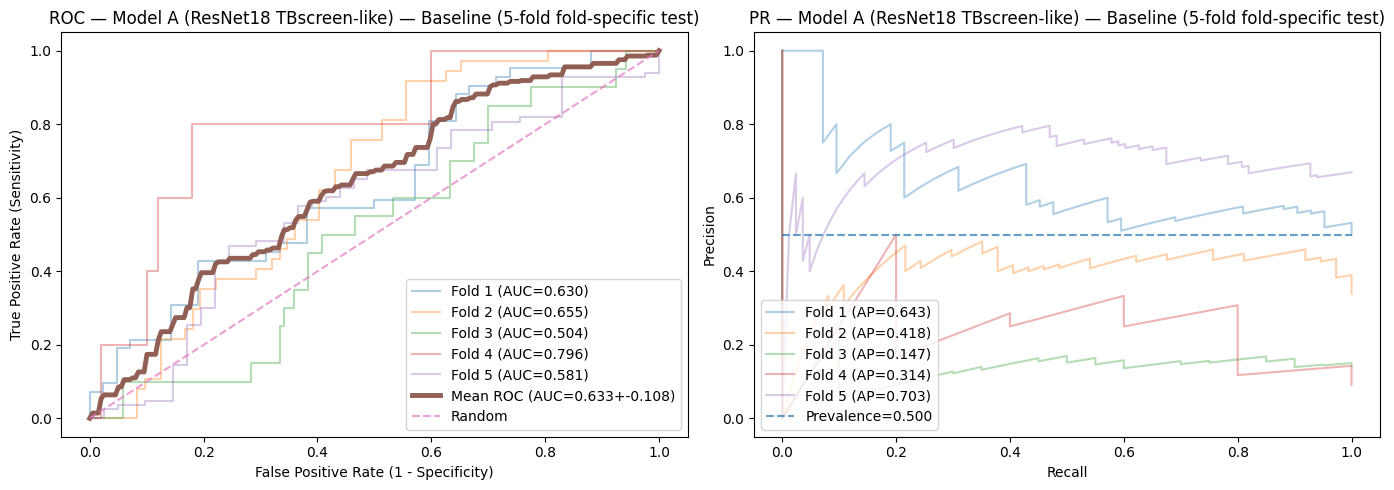

✅ Saved ROC/PR to: reports_tb_screen_like_scalo


In [19]:
#BLOCK 016C — Plot ROC/PR baseline (5-fold fold-specific test)

from pathlib import Path
out_dir = Path(config.output_dir)

for model_key in sorted(set([r["model_key"] for r in run_results_baseline])):
    plot_runs_roc_pr_new(
        run_results=run_results_baseline,
        model_key=model_key,
        out_path=str(out_dir / f"ROC_PR_{model_key.replace(' ', '_')}_baseline.png"),
        title_prefix=f"{model_key} — Baseline (5-fold fold-specific test)",
        show=True
    )

print("✅ Saved ROC/PR to:", out_dir)

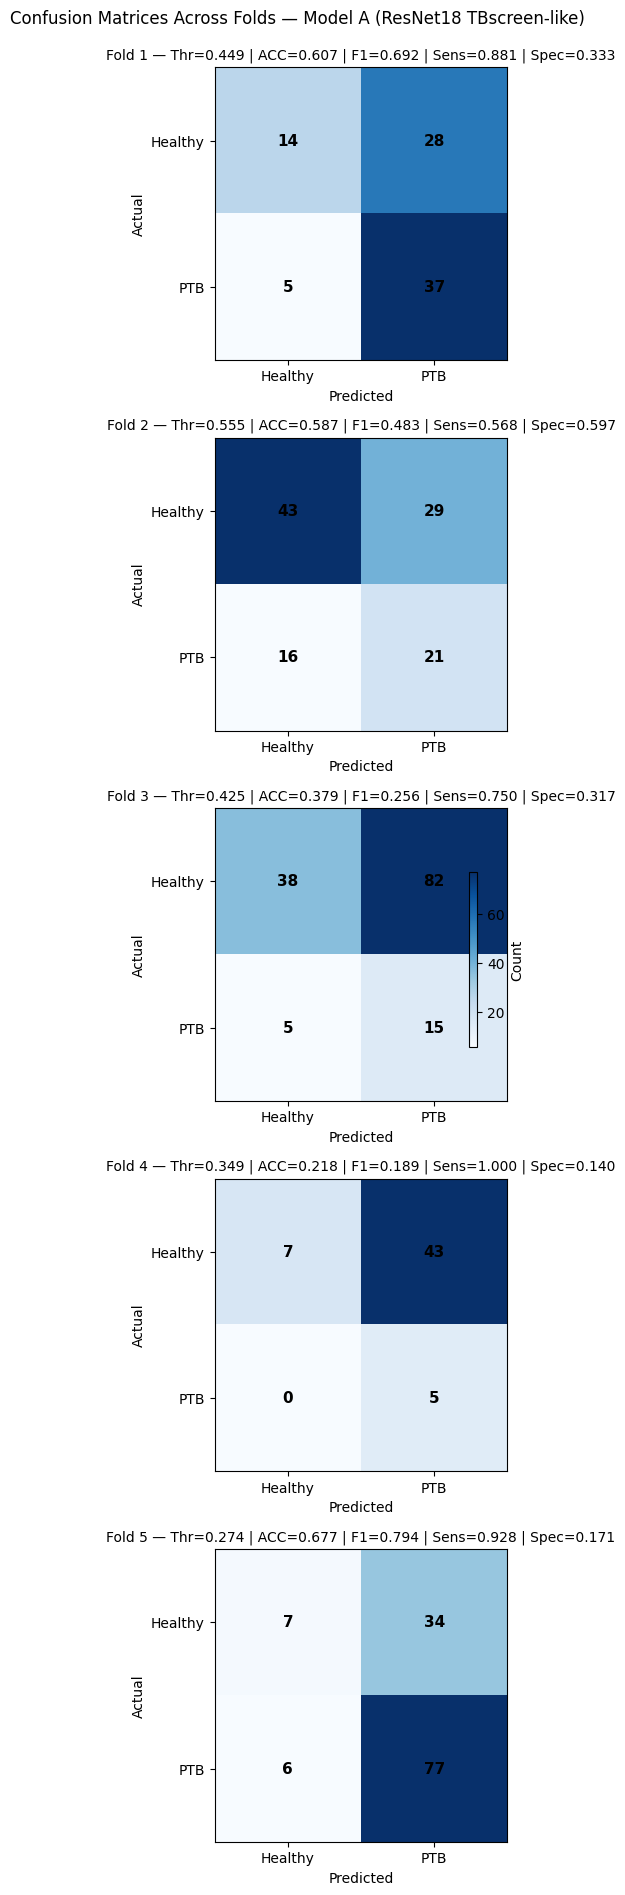

✅ Saved confusion matrix figure: reports_tb_screen_like_scalo\ConfusionMatrix_Model_A__ResNet18_TBscreen_like_baseline.png


In [20]:
#BLOCK 016D — Confusion matrix of each fold (fold-specific test)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _safe_slug(text: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in str(text)).strip("_")

def plot_confusion_matrices_per_fold(run_results, output_dir, show=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model_keys = sorted(set([r["model_key"] for r in run_results]))

    for model_key in model_keys:
        rows = sorted(
            [r for r in run_results if r.get("model_key") == model_key],
            key=lambda x: x.get("run", 0)
        )
        if len(rows) == 0:
            continue

        n = len(rows)
        fig, axes = plt.subplots(n, 1, figsize=(4.5, 3.8 * n))
        if n == 1:
            axes = [axes]

        im = None
        for ax, res in zip(axes, rows):
            tm = res.get("test_metrics", {})
            tn = int(tm.get("tn", 0))
            fp = int(tm.get("fp", 0))
            fn = int(tm.get("fn", 0))
            tp = int(tm.get("tp", 0))

            cm = np.array([[tn, fp], [fn, tp]], dtype=int)
            im = ax.imshow(cm, cmap="Blues")

            for i in range(2):
                for j in range(2):
                    ax.text(
                        j, i, str(cm[i, j]),
                        ha="center", va="center",
                        fontsize=11, fontweight="bold", color="black"
                    )

            run = res.get("run", "?")
            thr = float(res.get("selected_threshold", np.nan))
            acc = float(tm.get("accuracy", np.nan))
            f1 = float(tm.get("f1", np.nan))
            sens = float(tm.get("sensitivity", np.nan))
            spec = float(tm.get("specificity", np.nan))

            ax.set_title(
                f"Fold {run} — Thr={thr:.3f} | ACC={acc:.3f} | F1={f1:.3f} | Sens={sens:.3f} | Spec={spec:.3f}",
                fontsize=10
            )
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Healthy", "PTB"])
            ax.set_yticks([0, 1])
            ax.set_yticklabels(["Healthy", "PTB"])
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")

        if im is not None:
            cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
            cbar.ax.set_ylabel("Count", rotation=90)

        fig.suptitle(f"Confusion Matrices Across Folds — {model_key}", fontsize=12, y=0.995)
        fig.tight_layout()

        save_path = output_dir / f"ConfusionMatrix_{_safe_slug(model_key)}_baseline.png"
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
        if show:
            plt.show()
        plt.close(fig)

        print(f"✅ Saved confusion matrix figure: {save_path}")

plot_confusion_matrices_per_fold(run_results_baseline, out_dir, show=True)

In [21]:
#FINAL CHECK — Print train/val/test subject IDs per fold + leakage checks

def print_patient_ids(split_info, show_sorted=True):
    def _fmt(lst):
        lst = [str(x) for x in lst]
        return sorted(lst) if show_sorted else lst

    print("\n" + "=" * 90)
    print("PATIENT ID LISTS (subject_id) — 5-FOLD SUBJECT-LEVEL SKF")
    print("=" * 90)

    all_test_subjects = []

    for r in split_info["runs"]:
        fold_id = r["run"]
        tr = _fmt(r["train_subjects"])
        va = _fmt(r["val_subjects"])
        te = _fmt(r["test_subjects"])
        all_test_subjects.extend(te)

        inter_tr_va = set(tr) & set(va)
        inter_tr_te = set(tr) & set(te)
        inter_va_te = set(va) & set(te)

        print("\n" + "-" * 90)
        print(f"Fold {fold_id}")
        print(f"- Train subjects ({len(tr)}): {tr}")
        print(f"- Val   subjects ({len(va)}): {va}")
        print(f"- Test  subjects ({len(te)}): {te}")
        print(f"- Leakage check Train∩Val: {sorted(list(inter_tr_va))}  {'✅' if len(inter_tr_va)==0 else '❌'}")
        print(f"- Leakage check Train∩Test: {sorted(list(inter_tr_te))}  {'✅' if len(inter_tr_te)==0 else '❌'}")
        print(f"- Leakage check Val∩Test: {sorted(list(inter_va_te))}  {'✅' if len(inter_va_te)==0 else '❌'}")

    unique_test = set(all_test_subjects)
    dup_test = sorted([sid for sid in unique_test if all_test_subjects.count(sid) > 1])

    print("\n" + "=" * 90)
    print(f"Total test assignments: {len(all_test_subjects)}")
    print(f"Unique test subjects  : {len(unique_test)}")
    print(f"Duplicate test IDs    : {dup_test}")
    print("Cross-fold test coverage check:", "✅" if len(all_test_subjects) == len(unique_test) else "⚠️ CHECK")

print_patient_ids(split_info, show_sorted=True)


PATIENT ID LISTS (subject_id) — 5-FOLD SUBJECT-LEVEL SKF

------------------------------------------------------------------------------------------
Fold 1
- Train subjects (9): ['005', '006', '007', '009', '011', '013', '014', '015', '016']
- Val   subjects (3): ['002', '004', '012']
- Test  subjects (3): ['001', '003', '008']
- Leakage check Train∩Val: []  ✅
- Leakage check Train∩Test: []  ✅
- Leakage check Val∩Test: []  ✅

------------------------------------------------------------------------------------------
Fold 2
- Train subjects (9): ['001', '003', '006', '007', '008', '009', '012', '014', '016']
- Val   subjects (3): ['002', '004', '011']
- Test  subjects (3): ['005', '013', '015']
- Leakage check Train∩Val: []  ✅
- Leakage check Train∩Test: []  ✅
- Leakage check Val∩Test: []  ✅

------------------------------------------------------------------------------------------
Fold 3
- Train subjects (9): ['001', '003', '004', '006', '008', '009', '013', '014', '016']
- Val   subje

In [22]:
import matplotlib.pyplot as plt

def plot_loss_curve(history, title="Loss curve"):
    e = history["epoch"]
    plt.figure()
    plt.plot(e, history["train_loss"], label="train")
    plt.plot(e, history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("✅ plot_loss_curve utility ready")

✅ plot_loss_curve utility ready
